In [58]:
from rdkit import Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns
import numpy as np

In [2]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)
drugbank_df

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...


In [3]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)
zinc_df

,source,mol
id,,
ZINCtA000001eUS8,zinc,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
ZINCpo00001BLwat,zinc,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
ZINCtz000004JjrO,zinc,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
ZINCsN000009NpXg,zinc,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
ZINCsN000009NsBY,zinc,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
...,...,...
ZINCrn00001eRwYj,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000024510A...
ZINCsN000009Nrlo,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000024510A...
ZINCtB00000oxE6f,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000024510A...


In [4]:
mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)
mtor_df

,source,mol
id,,
CHEMBL1773577,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
CHEMBL1773561,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
CHEMBL1773077,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
CHEMBL1773580,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
CHEMBL1773578,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002451C8...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002451C8...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002451C8...


In [5]:
structures = pd.concat([drugbank_df, zinc_df, mtor_df])

In [ ]:
mol=Chem.MolFromSmiles("NCCCCc1ccncc1")

In [28]:
p_b = Chem.MolFromSmarts("c1ccccc1")
p_h = Chem.MolFromSmarts("C1CCCCC1")
structures["hB"] = structures["mol"].apply(lambda x: x.HasSubstructMatch(p_b) and not x.HasSubstructMatch(p_h))
structures["hH"] = structures["mol"].apply(lambda x: x.HasSubstructMatch(p_h) and not x.HasSubstructMatch(p_b))
structures["hBoth"] = structures["mol"].apply(lambda x: x.HasSubstructMatch(p_h) and x.HasSubstructMatch(p_b))

In [29]:
structures.groupby(by="source")[["hH", "hB", "hBoth"]].sum()

,hH,hB,hBoth
source,,,
chembl,46,3598,79
drugbank,341,4063,225
zinc,577,2227,131


In [25]:
structures.groupby(by="source")["source"].count()

source
chembl      4596
drugbank    7120
zinc        7180
Name: source, dtype: int64

In [32]:
p_b = Chem.MolFromSmarts("c1ccccc1")
p_h = Chem.MolFromSmarts("C1CCCCC1")
structures["cB"] = structures["mol"].apply(lambda x: len(x.GetSubstructMatches(p_b)))
structures["cH"] = structures["mol"].apply(lambda x: len(x.GetSubstructMatches(p_h)))

In [33]:
structures

,source,mol,hB,hH,hBoth,cB,cH
id,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,True,False,False,3,0
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,True,False,False,2,0
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,True,False,False,2,0
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,True,False,False,4,0
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,False,False,False,0,0
...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002451C8...,True,False,False,1,0
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002451C8...,True,False,False,1,0
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002451C8...,True,False,False,2,0


<Axes: xlabel='cB', ylabel='Count'>

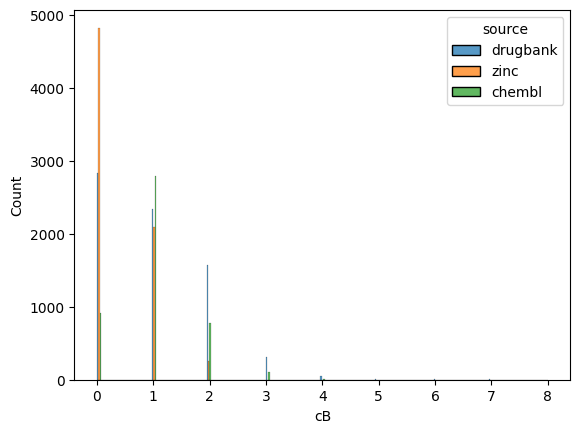

In [38]:
sns.histplot(data=structures, x="cB", hue="source", multiple="dodge")

<Axes: xlabel='cB', ylabel='source'>

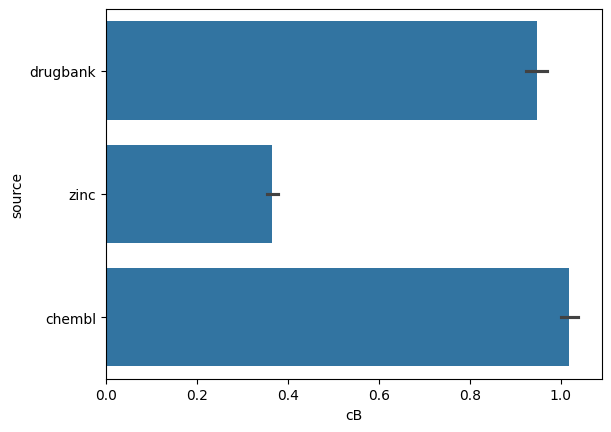

In [41]:
sns.barplot(data=structures, x="cB", y="source")

<Axes: xlabel='cH', ylabel='Count'>

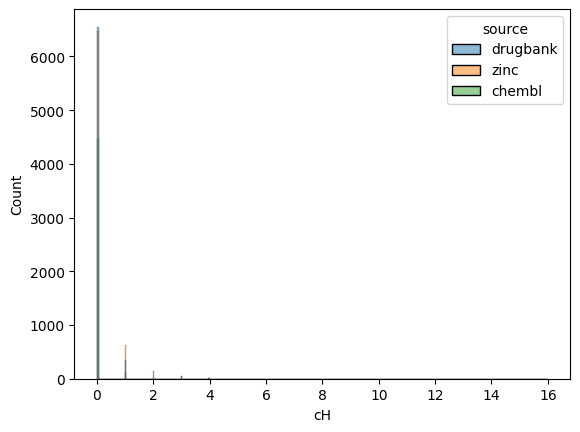

In [36]:
sns.histplot(data=structures, x="cH", hue="source")

In [43]:
pains = {}
with open("../data/pains/p_l15.txt") as inp:
    for line in inp:
        p,n = line.strip().split("\t")
        pains[n.replace('<regId="','').replace('">','')] = Chem.MolFromSmarts(p)
with open("../data/pains/p_m150.txt") as inp:
    for line in inp:
        p,n = line.strip().split("\t")
        pains[n.replace('<regId="','').replace('">','')] = Chem.MolFromSmarts(p)

In [64]:
issues = {}
for k, p in pains.items():
    matches  = structures["mol"].apply(lambda x: x.HasSubstructMatch(p))
    issues[k] = np.nonzero(matches)

In [103]:
ps=Chem.MolFromSmarts("C~1~C~C~2~C(~C~C1)~C~3~C~C~C~4~C(~C~C~C4~C3~C~C2)")

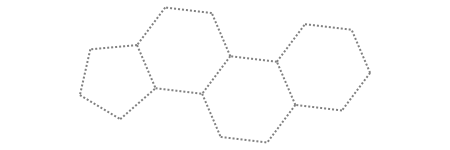

In [104]:
ps

In [106]:
structures["steroid"] = structures["mol"].apply(lambda x: x.HasSubstructMatch(ps))

In [107]:
structures[structures["steroid"]]

,source,mol,hB,hH,hBoth,cB,cH,steroid
id,,,,,,,,
DB00180,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,False,True,False,0,2,True
DB00223,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,False,True,False,0,2,True
DB00240,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,False,True,False,0,2,True
DB00253,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,False,True,False,0,2,True
DB00288,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000245039...,False,True,False,0,2,True
...,...,...,...,...,...,...,...,...
DB09389,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...,False,True,False,0,2,True
DB11619,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...,False,False,False,0,0,True
DB11622,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002450AA...,False,True,False,0,3,True


In [113]:
m=structures.loc["DB11619"]["mol"]
m.GetSubstructMatches(ps)

((21, 19, 15, 13, 18, 20, 9, 12, 10, 2, 5, 7, 6, 3, 4, 11, 14),)

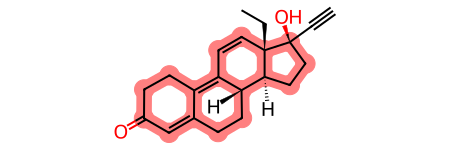

In [114]:
m